# Contextual Behaviour Analysis

## Objective

The goal of this project is to examine how multiple contextual and intake-level variables relate to behavioural outcomes.

In the previous notebook, the analysis focused on individual variables in isolation. Here, the focus shifts to how variables interact with each other by combining session-level behavioural data with client intake data.

Key questions explored in this analysis:

- How do sleep and environmental noise interact in relation to behaviour?
- Do antecedent patterns differ across settings?
- Do intake-level characteristics provide meaningful context for session-level behaviour?

## Why this matters

In practice, behaviour is rarely driven by a single variable. It typically emerges from a combination of environmental conditions, antecedents, and individual differences.

This analysis moves toward a more realistic representation of behaviour by examining how these factors appear together, rather than independently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sessions = pd.read_csv('../data/aba_behavior_synthetic.csv')
clients = pd.read_csv('../data/client_profiles.csv')

In [3]:
sessions.head()

,session_id,date,client_id,hours_slept,screen_time_hours,sugar_intake,noise_level,routine_change,setting,antecedent,session_period,behavior_occurred,behavior_type,behavior_intensity
0,S000001,2024-01-01,1027,9.5,3.5,3,8,0,School,Denied Access,Midday,1,Property Destruction,4
1,S000002,2024-01-01,1046,5.8,2.0,4,8,0,School,Peer Conflict,Evening,0,NaN,0
2,S000003,2024-01-01,1015,8.2,3.1,2,3,0,Home,Demand,Morning,1,Property Destruction,3
3,S000004,2024-01-01,1025,6.8,1.9,3,8,0,School,Demand,Afternoon,1,Property Destruction,1
4,S000005,2024-01-01,1012,8.4,4.0,0,2,0,Home,Demand,Evening,1,Aggression,1


In [4]:
clients.head()

,client_id,age_at_intake,age_band,gender,primary_language,diagnosis,medication_status,communication_type,communication_level,adaptive_functioning_level,social_functioning_level,school_status,therapy_setting_primary,reported_sleep_issues,reported_dietary_concerns,primary_behaviour_topographies,reported_behaviour_severity,known_triggers_reported,preferred_reinforcers
0,1000,4,3-5,Male,Mandarin,ASD + ADHD,NaN,Gestural / Emerging,Phrases,Moderate support,Emerging,Mainstream,Clinic,No,No,Tantrum; Elopement,Moderate,Transitions,Social praise
1,1001,12,12-14,Male,Punjabi,ASD + ADHD,Active medication,Vocal,Sentences,Lower support,Developing,Mainstream,Home,Yes,Yes,Tantrum; Aggression,Severe,Unclear / mixed,Screens / Videos
2,1002,13,12-14,Male,English,ASD,NaN,Vocal,Phrases,Moderate support,More independent,Specialized classroom,Clinic,No,No,Self-Injury,Moderate,Demands; Transitions,Toys / Tangibles
3,1003,7,6-8,Male,English,ASD + Anxiety,Active medication,AAC,Phrases,Moderate support,Developing,Not school-aged,Clinic,No,No,Property Destruction,Severe,Demands; Transitions,Social praise
4,1004,4,3-5,Male,English,ASD,NaN,Vocal,Sentences,High support,Emerging,Mainstream,Clinic,No,No,Tantrum; Elopement,Moderate,Denied access,Mixed


## Data Integration

This analysis combines two datasets:

1. A session-level dataset where each row represents a single observed session  
2. A client intake dataset containing baseline information available at intake or early assessment  

The datasets are linked using `client_id`.

Merging them allows the analysis to include both:

- session-level variables such as sleep, noise, setting, and antecedent  
- intake-level variables such as diagnosis, communication level, and reported behaviour severity  

This structure makes it possible to examine behaviour within context rather than treating each observation independently.

In [5]:
df = pd.merge(sessions, clients, on='client_id', how='left')
df.head()

,session_id,date,client_id,hours_slept,screen_time_hours,sugar_intake,noise_level,routine_change,setting,antecedent,...,adaptive_functioning_level,social_functioning_level,school_status,therapy_setting_primary,reported_sleep_issues,reported_dietary_concerns,primary_behaviour_topographies,reported_behaviour_severity,known_triggers_reported,preferred_reinforcers
0,S000001,2024-01-01,1027,9.5,3.5,3,8,0,School,Denied Access,...,Moderate support,Emerging,Not school-aged,Clinic,No,No,Tantrum; Elopement,Moderate,Sensory overload,Toys / Tangibles
1,S000002,2024-01-01,1046,5.8,2.0,4,8,0,School,Peer Conflict,...,High support,Emerging,Not school-aged,School-based,Yes,No,Tantrum; Aggression,Severe,Demands,Mixed
2,S000003,2024-01-01,1015,8.2,3.1,2,3,0,Home,Demand,...,High support,Developing,Specialized classroom,Clinic,Yes,No,Tantrum,Severe,Denied access,Toys / Tangibles
3,S000004,2024-01-01,1025,6.8,1.9,3,8,0,School,Demand,...,Lower support,Developing,Not school-aged,Clinic,Yes,No,Tantrum; Elopement,Moderate,Denied access; Transitions,Edibles
4,S000005,2024-01-01,1012,8.4,4.0,0,2,0,Home,Demand,...,High support,Emerging,Specialized classroom,Clinic,No,No,Property Destruction,Mild,Denied access; Transitions,Breaks / Escape


In [6]:
df.shape

(6000, 32)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   session_id                      6000 non-null   str    
 1   date                            6000 non-null   str    
 2   client_id                       6000 non-null   int64  
 3   hours_slept                     6000 non-null   float64
 4   screen_time_hours               6000 non-null   float64
 5   sugar_intake                    6000 non-null   int64  
 6   noise_level                     6000 non-null   int64  
 7   routine_change                  6000 non-null   int64  
 8   setting                         6000 non-null   str    
 9   antecedent                      6000 non-null   str    
 10  session_period                  6000 non-null   str    
 11  behavior_occurred               6000 non-null   int64  
 12  behavior_type                   2973 non-null

## Merge Validation and Initial Data Check

In [8]:
df.isna().sum().sort_values(ascending=False)

medication_status                 3364
behavior_type                     3027
session_id                           0
primary_language                     0
known_triggers_reported              0
reported_behaviour_severity          0
primary_behaviour_topographies       0
reported_dietary_concerns            0
reported_sleep_issues                0
therapy_setting_primary              0
school_status                        0
social_functioning_level             0
adaptive_functioning_level           0
communication_level                  0
communication_type                   0
diagnosis                            0
gender                               0
date                                 0
age_band                             0
age_at_intake                        0
behavior_intensity                   0
behavior_occurred                    0
session_period                       0
antecedent                           0
setting                              0
routine_change           

In [9]:
df[[ 'client_id', 'diagnosis', 'communication_level', 'reported_behaviour_severity']].head()

,client_id,diagnosis,communication_level,reported_behaviour_severity
0,1027,ASD,Sentences,Moderate
1,1046,ASD,Single words,Severe
2,1015,ASD + ADHD,Single words,Severe
3,1025,ASD,Single words,Moderate
4,1012,ASD + Other,Single words,Mild


## Analysis Plan

This notebook focuses on three main objectives:

1. Create analysis-friendly variables through grouping and preprocessing  
2. Examine how variables interact with each other in relation to behaviour  
3. Identify patterns that are not visible in single-variable analysis  

The emphasis is on exploring relationships and structure in the data rather than building predictive models at this stage.

## Preprocessing: Creating Analysis-Friendly Variables

Some continuous variables are easier to interpret when grouped into categories.

In this analysis:

- Sleep is grouped into ranges (e.g., <6, 6–8, 8–10 hours)  
- Noise is grouped into levels (Low to Very High)  

These groupings simplify interpretation and make multivariate comparisons more readable in visualizations.

The goal is not to reduce precision, but to make patterns across combinations of variables easier to identify.

In [10]:
df['sleep_bucket'] = pd.cut(
    df['hours_slept'],
    bins=[0, 6, 8, 10, 24],
    labels=['<6', '6–8', '8–10', '>10'],
    include_lowest=True
)

In [11]:
df['noise_bucket'] = pd.cut(
    df['noise_level'],
    bins=[-1, 2, 5, 8, 10],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

In [12]:
df[[ 'hours_slept', 'sleep_bucket', 'noise_level', 'noise_bucket']].head()

,hours_slept,sleep_bucket,noise_level,noise_bucket
0,9.5,8–10,8,High
1,5.8,<6,8,High
2,8.2,8–10,3,Moderate
3,6.8,6–8,8,High
4,8.4,8–10,2,Low


## Multivariate Analysis 1: Sleep and Noise Together

This section examines how sleep and environmental noise relate to behaviour occurrence when considered together.

Both variables showed meaningful relationships with behaviour in the previous analysis. Looking at them jointly helps determine whether their effects are independent or interacting.

In [13]:
sleep_noise_table = pd.pivot_table(
    df,
    values='behavior_occurred',
    index='sleep_bucket',
    columns='noise_bucket',
)

sleep_noise_table = sleep_noise_table.sort_index(ascending=False)
sleep_noise_table

noise_bucket,Low,Moderate,High,Very High
sleep_bucket,,,,
>10,0.251908,0.404070,0.538745,0.750000
8–10,0.280488,0.431484,0.564193,0.707865
6–8,0.195946,0.389423,0.512144,0.722581
<6,0.187500,0.493392,0.618667,0.793970


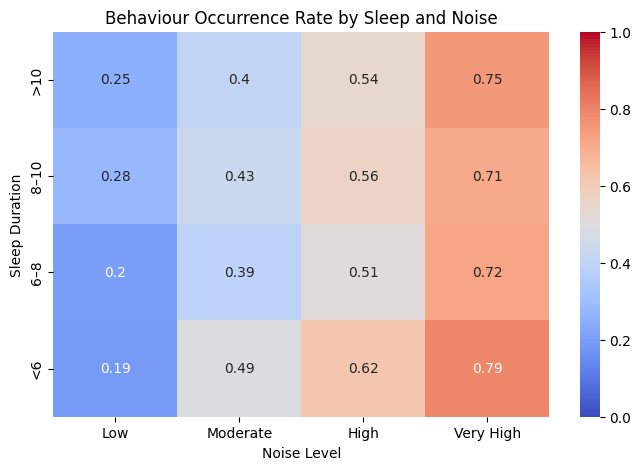

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(data=sleep_noise_table,
            vmin=0, vmax=1,
            cmap='coolwarm',
            annot=True)
plt.title('Behaviour Occurrence Rate by Sleep and Noise')
plt.xlabel('Noise Level')
plt.ylabel('Sleep Duration')
plt.show()

### Observations

- Behaviour occurrence increases consistently as noise levels increase across all sleep categories  
- Differences between sleep categories become more noticeable at moderate and high noise levels  
- At very high noise levels, behaviour occurrence is elevated regardless of sleep duration  

### Interpretation

Noise appears to have a strong and consistent association with behaviour.

Sleep shows a more context-dependent pattern. Lower sleep is associated with higher behaviour occurrence, but mainly when noise levels are not already extreme.

At very high noise levels, the effect of sleep becomes less distinguishable, suggesting that environmental conditions may dominate in those cases.

### Takeaway

Behaviour appears to be influenced by the combination of physiological and environmental factors rather than either variable alone.

## Multivariate Analysis 2: Setting and Antecedent

This section explores how behavioural antecedents relate to behaviour across different settings.

Antecedents such as demands, transitions, and denied access are commonly associated with problem behaviour, but their impact may vary depending on context.

In [15]:
setting_antecedent_table = pd.pivot_table(
    df,
    values='behavior_occurred',
    index='setting',
    columns='antecedent',
)

setting_antecedent_table

antecedent,Attention Removed,Demand,Denied Access,Peer Conflict,Transition
setting,,,,,
Clinic,0.471649,0.548128,0.463215,0.454774,0.577830
Home,0.403183,0.543424,0.408115,0.419178,0.550691
School,0.468085,0.621749,0.466667,0.438967,0.578406


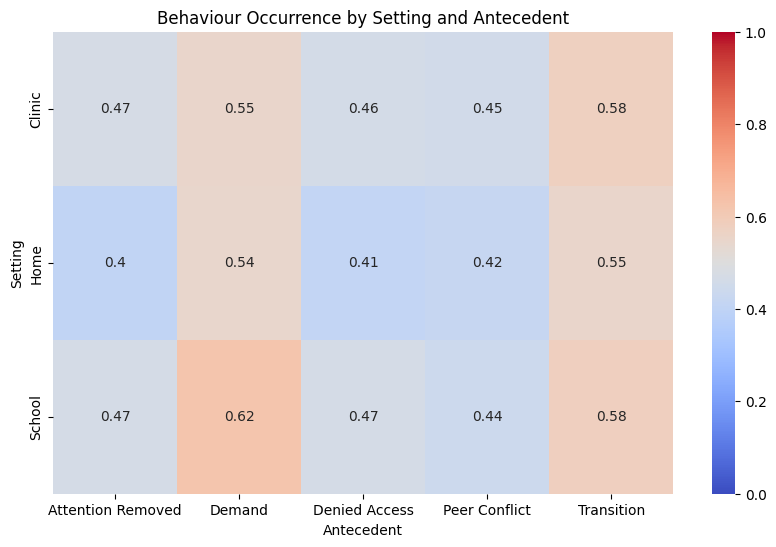

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=setting_antecedent_table,
            vmin=0, vmax=1,
            cmap='coolwarm',
            annot=True)

plt.title('Behaviour Occurrence by Setting and Antecedent')
plt.xlabel('Antecedent')
plt.ylabel('Setting')

plt.show()

### Observations

- Demand and transition are associated with the highest behaviour occurrence across all settings  
- Behaviour occurrence is generally higher in school compared to home  
- Clinic and school show similar patterns, with slightly elevated rates compared to home  
- Other antecedents show more moderate and consistent values across settings  

### Interpretation

Demand appears to be the strongest trigger, particularly in school settings.

Transitions also show consistently elevated behaviour rates, especially in structured environments like school and clinic.

The higher rates in school suggest that increased task demands and structured expectations may contribute to behavioural risk.

### Takeaway

The same antecedent does not have a uniform effect across environments. Context plays a key role in how behavioural triggers are expressed.

## Multivariate Analysis 3: Client Characteristics

This section examines whether intake-level variables are associated with behavioural outcomes.

The focus is on:
- reported behaviour severity  
- communication level  

In [17]:
severity_table = pd.pivot_table(
    df,
    values='behavior_occurred',
    index='reported_behaviour_severity',
)

severity_table

,behavior_occurred
reported_behaviour_severity,
Mild,0.507371
Moderate,0.492812
Severe,0.494965


<Figure size 800x500 with 0 Axes>

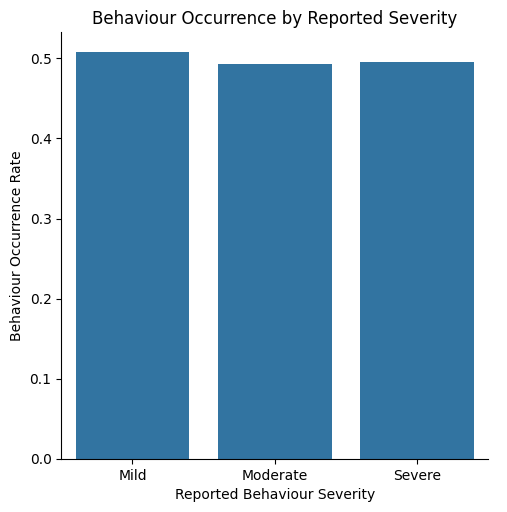

In [20]:
plt.figure(figsize=(8, 5))
sns.catplot(
    data=severity_table.reset_index(),
    x='reported_behaviour_severity',
    y='behavior_occurred',
    kind='bar',
)

plt.title('Behaviour Occurrence by Reported Severity')
plt.xlabel('Reported Behaviour Severity')
plt.ylabel('Behaviour Occurrence Rate')

plt.show()

In [23]:
comm_table = pd.pivot_table(
    df,
    values='behavior_intensity',
    index='communication_level',
)

comm_table

,behavior_intensity
communication_level,
Phrases,1.455583
Sentences,1.563300
Single words,1.450174


<Figure size 800x500 with 0 Axes>

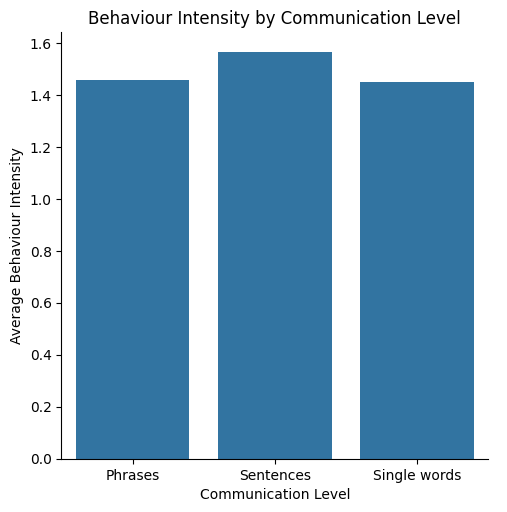

In [24]:
plt.figure(figsize=(8, 5))

sns.catplot(
    data=comm_table.reset_index(),
    x='communication_level',
    y='behavior_intensity',
    kind='bar',
)

plt.title('Behaviour Intensity by Communication Level')
plt.xlabel('Communication Level')
plt.ylabel('Average Behaviour Intensity')

plt.show()

In [25]:
setting_severity = pd.pivot_table(
    df,
    values='behavior_occurred',
    index='reported_behaviour_severity',
    columns='setting',
)

setting_severity

setting,Clinic,Home,School
reported_behaviour_severity,,,
Mild,0.515504,0.492537,0.513889
Moderate,0.502379,0.456744,0.519553
Severe,0.503115,0.474809,0.506531


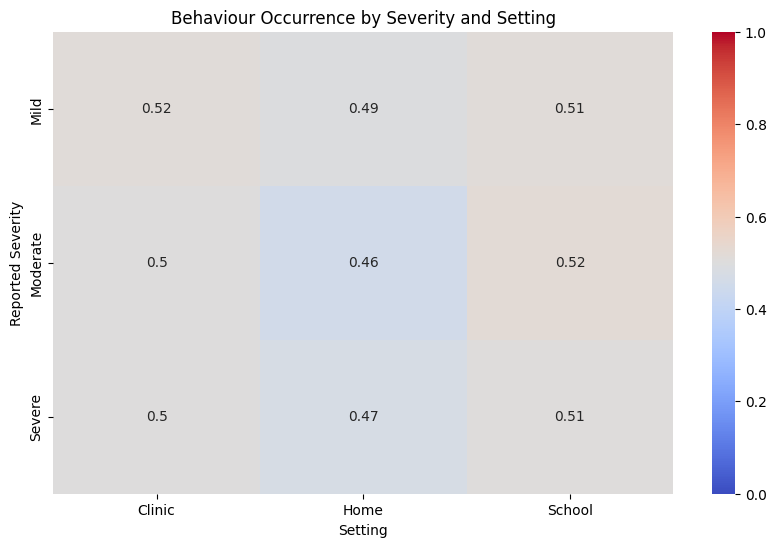

In [26]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    data=setting_severity,
    vmin=0, vmax=1,
    cmap='coolwarm',
    annot=True
)

plt.title('Behaviour Occurrence by Severity and Setting')
plt.xlabel('Setting')
plt.ylabel('Reported Severity')

plt.show()

### Observations

- Behaviour occurrence rates are similar across mild, moderate, and severe categories  
- Average behaviour intensity is relatively consistent across communication levels  
- Small differences appear across settings, with slightly lower behaviour at home  

### Interpretation

Reported severity does not strongly differentiate behaviour occurrence at the session level.

Similarly, communication level does not show a clear relationship with behaviour intensity in this dataset.

While small differences exist across settings, they are modest and do not suggest strong interaction effects.

### Takeaway

Intake-level characteristics provide background context but do not appear to strongly explain behaviour on their own in this dataset.

## Conclusion

This project examined how contextual, environmental, and intake-level variables relate to behavioural outcomes using a multivariate approach.

Compared to the previous analysis, this notebook focused on how variables appear together rather than independently.

Across the analyses:

- Environmental and contextual variables showed more consistent relationships with behaviour  
- Higher noise levels and lower sleep were associated with increased behaviour occurrence  
- Demand and transition were associated with higher behaviour rates across settings  
- Behaviour occurrence was slightly lower at home compared to school and clinic  

In contrast:

- Intake-level variables such as reported severity and communication level showed limited differentiation  

These results suggest that behaviour is more closely associated with situational factors than with static client characteristics.

This analysis is exploratory and does not formally model interactions. It identifies patterns but does not quantify the relative contribution of variables.

Overall, this serves as a foundation for moving toward more structured modelling approaches.

## Key Takeaways

- Behaviour occurrence increases with higher noise levels and lower sleep  
- Demand and transition are associated with higher behaviour rates  
- Behaviour occurrence is slightly lower at home than in school or clinic settings  
- Intake-level variables show limited differentiation in behaviour outcomes  
- Contextual and environmental variables appear more informative than static client characteristics  
- The analysis highlights potential interactions but does not formally model them  

## Next Steps

This analysis focused on identifying patterns through grouped comparisons and visualizations.

The next step is to move toward structured modelling approaches that can quantify these relationships.

Planned steps include:

- Building regression models to estimate the relationship between predictors and behaviour  
- Examining multiple variables within the same model  
- Performing feature selection to identify the most informative variables  
- Evaluating model performance and interpreting coefficients  

The goal is to transition from exploratory analysis to models that can better capture how multiple factors contribute to behavioural outcomes.